# Applying DeepRV to IPMs
In this notebook, we aim to use **DeepRV** to replace sampling from a Gaussian process, and then apply this idea to Bayesian vital rate fitting in integral projection models (IPMs).

Let $(s \in \mathbb{R}^n)$ denote a fixed set of input points, and let $(k_{\theta}(\cdot,\cdot))$ be a kernel function with parameters $(\theta)$. We assume
$$
f(s) \sim \mathcal{GP}(0, K_{\theta}),
\qquad
(K_{\theta})_{ij} = k_{\theta}(s_i, s_j).
$$

Equivalently, a draw from the Gaussian process can be written as

$$
f(s) = L_{\theta} z,
\qquad
z \sim \mathcal{N}(0, I_n),
\qquad
L_{\theta} = \mathrm{chol}(K_{\theta}).
$$

Since the Cholesky decomposition of an $(n \times n)$ matrix scales as $(O(n^3))$, we hope to train a neural network that provides a faster approximation:

$$
\mathrm{DeepRV}(\theta, z) \approx f(s).
$$

---
In general, the hierarchy is

$$
\theta \sim p(\theta),
$$

$$
f(s) \mid \theta \sim \mathcal{GP}(0, K_{\theta})

$$

$$
y \sim \mathrm{p}\left(\kappa\left(f(s)\right)\right),
$$

where $\kappa(\cdot)$ is the inverse link function. Note that there are no observations for the mesh points.

The target posterior is therefore

$$
p(\theta, f \mid y)
\propto
p(\theta), p(f \mid \theta), p(y \mid f, \theta).
$$

During inference, we draw samples from this posterior using HMC. At each iteration of HMC, given the current state $(\theta, f)$, we must evaluate the log posterior:

$$
\log p(\theta, f \mid y)
=

\log p(\theta)
+
\log p(f \mid \theta)
+
\log p(y \mid f, \theta).
$$

In this segment, we extend DeepRV to fit all other vital rates and then construct an IPM using the posterior samples.

For the monocarp species, a standard GLM specification for the vital rates is:

1. **Growth**
   $$
   z_1 \mid z \sim \mathcal{N}\!\bigl(f(z), \sigma\bigr)
   $$

2. **Flowering**
   $$
   \text{Flowering}(z) \sim \mathrm{Bernoulli}\!\bigl(\sigma(f(z))\bigr)
   $$

3. **Survival**
   $$
   \text{Survival}(z) \sim \mathrm{Bernoulli}\!\bigl(\sigma(f(z))\bigr)
   $$

4. **Seed production**
   $$
   \text{SeedProduction}(z) \sim \mathrm{Poisson}\!\bigl(\exp(f(z))\bigr)
   $$

5. **Recruit size** [Note that recruit size is independent of parent size.]
   $$
   z_1 \sim \mathcal{N}(\mu, \sigma)
   $$
6. **Recruitment Probability**
    $$
    \mathrm{Recruit} \sim \mathrm{Bernoulli}\!\bigl(p_{\mathrm{recr}}\bigr)
    $$
   

Extending this to the GP framework, we have:

1. **Growth**
   $$
   f(z) \sim \mathcal{GP}(0, K)
   $$

2. **Flowering probability**
   $$
   p_f(z) = \sigma(f(z)), \qquad \text{Flowering}(z) \sim \mathrm{Bernoulli}(p_f(z))
   $$

3. **Survival probability**
   $$
   p_s(z) = \sigma(f(z)), \qquad \text{Survival}(z) \sim \mathrm{Bernoulli}(p_s(z))
   $$

4. **Seed production**
   $$
    \text{SeedProduction}(z) \sim \mathrm{Poisson}\!\bigl(\exp(f(z))\bigr)
   $$

5. **Recruit size**
   Since recruit size is independent of $z$, we use a fixed distribution, for example:
   $$
   z_1 \sim \Gamma(\alpha, \beta)
   $$

6. **Recruitment Probability**
    $$
    \mathrm{Recruit} \sim \mathrm{Bernoulli}\!\bigl(p_{\mathrm{recr}}\bigr)    
    $$

Since f depends on the Gaussian process draw, computing it directly requires the Cholesky decomposition, which is expensive. DeepRV is intended to replace this costly step with a faster neural network approximation.

We use simulated data from IBM simulations as ground truth labels. The data was simulated using fitted GP vital rate models. 


In [ ]:
import sys

sys.path.append("benchmarks/vae")
from functools import partial
from pathlib import Path
from typing import Callable, Optional, Union
import jax
from jax import Array, jit, random
import jax.numpy as jnp
from jax.scipy.linalg import solve_triangular
from jax.scipy.stats import norm
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import optax
from numpyro import distributions as dist
import json
from hydra.utils import instantiate
import orbax


from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from dl4bi_sps.kernels import rbf
from dl4bi_sps.utils import build_grid
from utils.plot_utils import plot_infer_trace

import wandb
from dl4bi.core.model_output import VAEOutput
from dl4bi.core.train import cosine_annealing_lr, train
from dl4bi.vae import gMLPDeepRV
from dl4bi.vae.train_utils import deep_rv_train_step, generate_surrogate_decoder
from deeprv_utils import hmc, gen_train_dataloader, valid_step, train_deeprv, run_gp_inference, run_deeprv_inference, compute_metrics, load_saved_deeprv

In [17]:
priors = {
    "ls": dist.HalfNormal(5.0), 
    "r": dist.HalfNormal(5.0),
    "obs_noise":dist.HalfNormal(5.0)
    }

In [2]:
sim_data = pd.read_csv("gp_sample250.csv")
sim_data.shape

(250, 8)

In [3]:
sim_data.head()

,id,year,z,z1,age,survived,reproduced,n_seeds
0,445141,39,1.068144,1.716993,2,1.0,0,NaN
1,110162,28,0.071170,NaN,0,0.0,0,NaN
2,266958,34,1.331782,2.654812,1,1.0,0,NaN
3,327160,35,-1.156128,NaN,0,0.0,0,NaN
4,367965,37,1.078800,NaN,1,0.0,0,NaN


In [4]:
sim_data.columns

Index(['id', 'year', 'z', 'z1', 'age', 'survived', 'reproduced', 'n_seeds'], dtype='object')

In [ ]:
# Full location array in the original sim_data row order
s_all = jnp.asarray(
    sim_data["z"].to_numpy(dtype="float32")
)[:, None]

surv_mask = (
    (sim_data["reproduced"] == 0)
    & sim_data["z"].notna()
    & sim_data["survived"].notna()
)

surv_idx = np.flatnonzero(surv_mask.to_numpy(dtype=bool))
s_surv = s_all[surv_idx]
y_surv = jnp.asarray(sim_data.loc[surv_mask,"survived",].to_numpy(dtype="float32"))

print("Full locations:", s_all.shape)
print("s_surv:", s_surv.shape)
print("y_surv:", y_surv.shape)
print("surv_idx:", surv_idx.shape)

Full locations: (250, 1)
Survival locations: (239, 1)
Survival observations: (239,)
Mask Shape: (239,)


In [ ]:
# Reproduction data
repr_mask = (
    (sim_data["reproduced"].notna())
)

repr_idx = np.flatnonzero(repr_mask.to_numpy(dtype=bool))
s_repr = s_all
y_repr = jnp.asarray(sim_data.loc[repr_mask,"reproduced"].to_numpy(dtype="float32"))

print("s_repr:", s_repr.shape)
print("y_repr:", y_repr.shape)
print("repr_idx:", repr_idx.shape)

s_repr: (250, 1)
y_repr: (250,)
repr_idx: (250,)


In [ ]:
# Seed data
seed_mask = ((sim_data["reproduced"] == 1) & sim_data["z"].notna() & sim_data["n_seeds"].notna())


seed_idx = np.flatnonzero(seed_mask.to_numpy(dtype=bool))
s_seed = s_all[seed_idx]
y_seed = jnp.asarray(sim_data.loc[seed_mask, "n_seeds"].to_numpy(dtype="float32"))
print("s_seed:", s_seed.shape)
print("y_seed:", y_seed.shape)
print("seed_idx:", seed_idx.shape)

s_seed: (11, 1)
y_seed: (11,)
seed_idx: (11,)


In [ ]:
#Growth data
growth_mask = ((sim_data["reproduced"] == 0)
                & (sim_data["survived"] == 1) 
                & sim_data["z"].notna() 
                & sim_data["z1"].notna())

growth_idx = np.flatnonzero(growth_mask.to_numpy(dtype=bool))
s_growth = s_all[growth_idx]
y_growth = jnp.asarray(sim_data.loc[growth_mask, "z1"].to_numpy(dtype="float32"))

print("s_growth:", s_growth.shape)
print("y_growth:", y_growth.shape)
print("growth_idx:", growth_idx.shape)

s_growth: (111, 1)
y_growth: (111,)
growth_idx: (111,)


In [9]:
# Load the trained model
loaded = load_saved_deeprv(
    "results/train_deeprv/N_250"
)

surrogate_decoder = loaded["decoder"]
s = loaded["s"]

print("Locations shape:", s.shape)
print("Metadata:", loaded["metadata"])

Locations shape: (250, 1)
Metadata: {'model_name': 'gMLPDeepRV', 'num_blks': 2, 'dataset_size': 250, 'input_dimension': 1, 's_shape': [250, 1], 'conditional_names': ['ls', 'r'], 'kernel_name': 'rbf', 'train_time_seconds': 586.340638659, 'num_train_steps': 100000, 'checkpoint_path': 'results/train_deeprv/N_250/model.ckpt', 'locations_path': 'results/train_deeprv/N_250/s.npy'}


In [24]:
np.testing.assert_allclose(
    np.asarray(s).squeeze(),
    sim_data["z"].to_numpy(dtype="float32"),
)

print("Loaded locations match sim_data row order")

Loaded locations match sim_data row order


In [ ]:
# Check that the loaded decoder works
num_draws = 8
rng = random.key(123)
jitter = 5e-4

z = random.normal(rng, shape=(num_draws, s.shape[0]),)
for ls_value in [0.2, 0.5, 1.0, 2.0, 5.0, 10.0]:
    ls = jnp.array(ls_value)
    f_hat = surrogate_decoder(z, jnp.array([ls]), s=s).squeeze(-1)
    K = (rbf(s, s, 1.0, ls)+ jitter * jnp.eye(s.shape[0]))
    L = jnp.linalg.cholesky(K)
    f_true = jnp.einsum("ij,bj->bi", L, z)
    rmse = jnp.sqrt(jnp.mean((f_hat - f_true) ** 2))
    true_rms = jnp.sqrt(jnp.mean(f_true ** 2))
    print(f"ls={ls_value:>4}: "f"relative RMSE={float(rmse / true_rms):.4f}")

ls= 0.2: relative RMSE=0.0786
ls= 0.5: relative RMSE=0.0374
ls= 1.0: relative RMSE=0.0208
ls= 2.0: relative RMSE=0.0115
ls= 5.0: relative RMSE=0.0076
ls=10.0: relative RMSE=0.0104


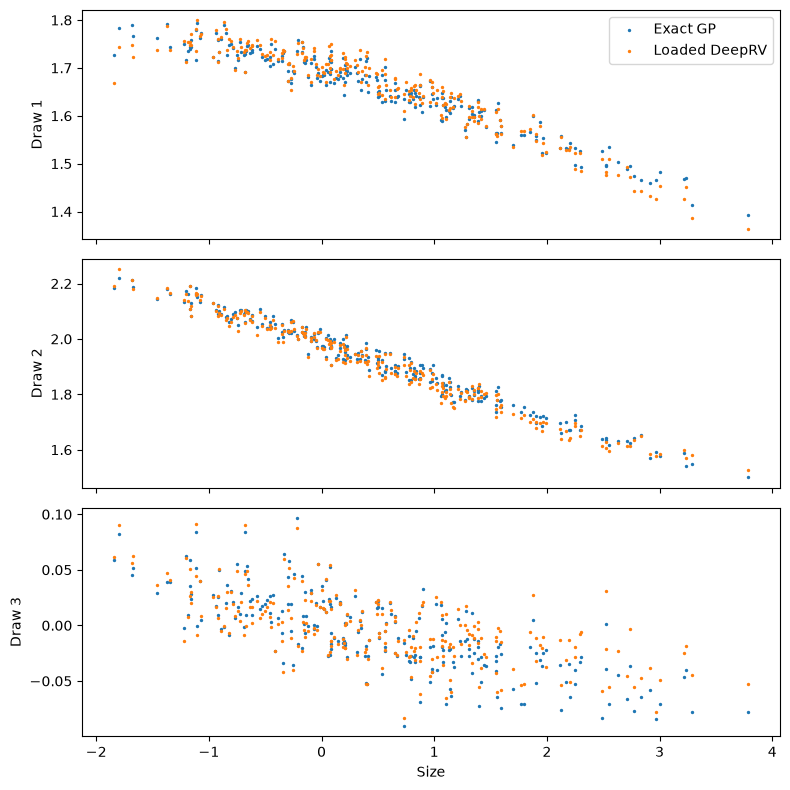

In [65]:
order = np.argsort(np.asarray(s).squeeze())
s_sorted = np.asarray(s).squeeze()[order]
f_true_np = np.asarray(f_true)
f_hat_np = np.asarray(f_hat)
fig, axes = plt.subplots(
    3,
    1,
    figsize=(8, 8),
    sharex=True,
)

for i, ax in enumerate(axes):
    ax.scatter(
        s_sorted,
        f_true_np[i, order],
        label="Exact GP",
        s=2,
    )

    ax.scatter(
        s_sorted,
        f_hat_np[i, order],
        label="Loaded DeepRV",
        s= 2,
    )

    ax.set_ylabel(f"Draw {i + 1}")

axes[0].legend()
axes[-1].set_xlabel("Size")
plt.tight_layout()
plt.show()

In [ ]:
def bernoulli_inference_model(s: Array, priors: dict, obs_idx: Array):
    """
    Builds a Bernoulli likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}
    s_obs = s[obs_idx,:]   #s is a (N,1)

    def bernoulli(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0])) #z is (1,N) 
        z_obs = z[:, obs_idx]
        if surrogate_decoder is None:
            K = rbf(s_obs, s_obs, var, ls) + 5e-4 * jnp.eye(s_obs.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z_obs[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit[obs_idx]
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
        p = jax.nn.sigmoid(mu)
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Bernoulli(probs=p), obs=y)

    return bernoulli

survival_model = partial(bernoulli_inference_model, obs_idx = surv_idx)
reproduction_model = partial(bernoulli_inference_model, obs_idx = repr_idx)

In [ ]:
def poisson_inference_model(s: Array, priors: dict, obs_idx: Array):
    """
    Builds a Poisson likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}
    s_obs = s[obs_idx, :]

    def poisson(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0])) #z is (1,N) 
        z_obs = z[:, obs_idx]
        if surrogate_decoder is None:
            K = rbf(s_obs, s_obs, var, ls) + 5e-4 * jnp.eye(s_obs.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z_obs[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit[obs_idx]
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
        lambda_ = jnp.exp(mu)
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Poisson(rate=lambda_), obs=y)

    return poisson

seed_model = partial(poisson_inference_model, obs_idx = seed_idx)

In [ ]:
def gaussian_inference_model(s: Array, priors: dict, obs_idx: Array):
    """
    Builds a Poisson likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}
    s_obs = s[obs_idx, :]

    def gaussian(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0]))
        z_obs = z[:, obs_idx]
        obs_noise = numpyro.sample("obs_noise", priors["obs_noise"])

        if surrogate_decoder is None:
            K = rbf(s_obs, s_obs, var, ls) + 5e-4 * jnp.eye(s_obs.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z_obs[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit[obs_idx]
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Normal(loc=mu, scale=obs_noise), obs=y)

    return gaussian

growth_model = partial(gaussian_inference_model, obs_idx = growth_idx)

In [ ]:
def inference_comparison(rng, s, y, priors, likelihood_model, surrogate_decoder, obs_mask=True):
    rng_gp, rng_deeprv = random.split(rng)
    gp_samples, gp_mcmc, gp_posterior, gp_timings = run_gp_inference(rng_gp, s, y, priors, likelihood_model, obs_mask)

    deeprv_samples, deeprv_mcmc, deeprv_posterior, deeprv_timings = run_deeprv_inference(rng_deeprv, s, y, priors, surrogate_decoder, likelihood_model, obs_mask)

    return {
        "gp": {
            "samples": gp_samples,
            "mcmc": gp_mcmc,
            "posterior": gp_posterior,
            "timings": gp_timings,
        },
        "deeprv": {
            "samples": deeprv_samples,
            "mcmc": deeprv_mcmc,
            "posterior": deeprv_posterior,
            "timings": deeprv_timings,
        },
    }

In [ ]:
rng = random.key(1)
rng_surv, rng_repr, rng_seed, rng_growth = random.split(rng, 4)

In [ ]:
survival_results = inference_comparison(
    rng_surv, 
    s, 
    y_surv.squeeze(), 
    priors, 
    survival_model, 
    surrogate_decoder
    )

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [09:48<00:00, 10.20it/s, 31 steps of size 1.64e-01. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        ls      2.90      1.49      2.59      0.66      5.02   5902.08      1.00
         r      4.16      2.76      3.55      0.41      8.22   8921.48      1.00
    z[0,0]      0.31      0.20      0.27      0.02      0.58   4302.51      1.00
    z[0,1]     -1.43      0.54     -1.38     -2.25     -0.56   8112.43      1.00
    z[0,2]     -0.08      0.86     -0.08     -1.44      1.35  12541.61      1.00
    z[0,3]     -0.49      0.84     -0.51     -1.81      0.93  11514.54      1.00
    z[0,4]      0.01      0.98      0.01     -1.60      1.63  21362.10      1.00
    z[0,5]     -0.00      1.02      0.00     -1.70      1.65  18569.61      1.00
    z[0,6]     -0.12      0.94     -0.11     -1.64      1.42  16930.30      1.00
    z[0,7]     -0.02      0.98     -0.02     -1.62      1.61  18081.83      1.00
    z[0,8]      0.07      1.00      0.07     -1.59      1.66  19355.94      1.00
    z[0,9]      0.04      0

NameError: name 'gp_samples' is not defined

In [ ]:
repr_results = inference_comparison(
    rng_repr, 
    s, 
    y_repr.squeeze(), 
    priors, 
    reproduction_model, 
    surrogate_decoder
    )

In [ ]:
seed_results = inference_comparison(
    rng_seed, 
    s, 
    y_seed.squeeze(), 
    priors, 
    seed_model, 
    surrogate_decoder
    )

In [ ]:
growth_results = inference_comparison(
    rng_growth, 
    s, 
    y_growth.squeeze(), 
    priors, 
    growth_model, 
    surrogate_decoder
    )

In [ ]:
# Recruitment Probability
n_recruits = int(((sim_data["age"] == 0) & sim_data["z"].notna()).sum())
total_seeds = int(np.nansum(sim_data["n_seeds"]))

if total_seeds == 0:
    raise ValueError("Recruitment probability cannot be estimated because total seed production is zero.")

if n_recruits > total_seeds:
    raise ValueError("The number of recruits cannot exceed the number of seeds.")

p_recruit_est = n_recruits / total_seeds

print("New recruits:", n_recruits)
print("Total seeds:", total_seeds)
print("Recruitment probability:", p_recruit_est)

In [ ]:
# Recruit Density
from scipy import stats

recruit_sizes = sim_data.loc[(sim_data["age"] == 0) & sim_data["z"].notna(), "z"].to_numpy()
recruit_mean_est, recruit_sd_est = stats.norm.fit(recruit_sizes)

print("Recruitment mean:", recruit_mean_est)
print("Recruitment SD:", recruit_sd_est)

## IPM Creation

In [ ]:
print(f"Max log(Size): {s.max()}")
print(f"Min log(Size): {s.min()}")

Max Size: 3.7872962951660156
Min Size: -1.8430702686309814


In [70]:
U = 4
L = -2
n_mesh_points = 100

In [71]:
mesh_width = (U - L)/ n_mesh_points
mesh_points = (L + (np.arange(n_mesh_points) + 0.5) * mesh_width)

### GP Prediction at the IPM Mesh

For each posterior draw, the latent GP values at the mesh points are obtained by conditioning on the sampled latent values at the observed locations:

$$f_m \mid f_o, r, \ell \sim \mathcal{N}(\mu_m, \Sigma_m)$$

The conditional mean and covariance are:

$$\mu_m = K_{mo}K_{oo}^{-1}f_o$$

$$\Sigma_m = K_{mm} - K_{mo}K_{oo}^{-1}K_{om}$$

Here, $K_{oo}$ is the covariance between observed locations, $K_{mo}$ is the covariance between mesh and observed locations, and $K_{mm}$ is the covariance between mesh points.

To calculate the conditional mean, the observed covariance matrix is first decomposed as:

$$K_{oo} = L_{oo}L_{oo}^T$$

Instead of explicitly calculating $K_{oo}^{-1}$, two triangular systems are solved:

$$L_{oo}\,\mathrm{tmp} = f_o$$

$$L_{oo}^T\alpha = \mathrm{tmp}$$

Therefore:

$$\alpha = {L_{oo}^T}^{-1}L_{oo}^{-1}f_o = K_{oo}^{-1}f_o$$

and the conditional mean is:

$$\mu_m = K_{mo}\alpha$$

The conditional covariance is calculated as:

$$\Sigma_m = K_{mm} - K_{mo}K_{oo}^{-1}K_{om}$$

A latent function at the mesh is then sampled as:

$$f_m = \mu_m + L_m\epsilon$$

where $L_mL_m^T = \Sigma_m$ and $\epsilon \sim \mathcal{N}(0,I)$. The observation likelihood has already been accounted for because $f_o$, $r$, and $\ell$ were sampled from their posterior distribution conditional on the observed data.

In [ ]:
def predict_gp_mesh(s_obs, mesh_points, f_obs, var, ls, jitter=5e-4):
    s_obs = jnp.asarray(s_obs).reshape(-1, 1)
    s_mesh = jnp.asarray(mesh_points).reshape(-1, 1)
    f_obs = jnp.asarray(f_obs).squeeze()

    K_oo = rbf(s_obs, s_obs, var, ls) + jitter * jnp.eye(s_obs.shape[0])
    K_mo = rbf(s_mesh, s_obs, var, ls)
    K_mm = rbf(s_mesh, s_mesh, var, ls) + jitter * jnp.eye(s_mesh.shape[0]) 

    L_oo = jnp.linalg.cholesky(K_oo)
    tmp = solve_triangular(L_oo, f_obs, lower=True)
    alpha = solve_triangular(L_oo.T, tmp, lower=False) 

    conditional_mean = K_mo @ alpha
    projected_covariance = solve_triangular(L_oo, K_mo.T, lower=True)
    conditional_covariance = K_mm - projected_covariance.T @ projected_covariance
    conditional_covariance = 0.5 * (conditional_covariance + conditional_covariance.T)
    conditional_covariance = conditional_covariance + 1e-6 * jnp.eye(s_mesh.shape[0])

    return conditional_mean, conditional_covariance

In [ ]:
def survival_kernel(mesh_points, survival_probability, reproduction_probability, growth_mean, growth_sd):
    '''
    P_density[i, j] - represents the transition probability from current size j to next size i
    '''

    growth_density = norm.pdf(mesh_points[:, None], loc=growth_mean[None, :], scale=growth_sd)
    non_reproductive_survival = survival_probability * (1.0 - reproduction_probability)
    return growth_density * non_reproductive_survival[None, :]

In [ ]:
def fecundity_kernel(mesh_points, reproduction_probability, expected_seed_count, recruitment, mesh_width):
    recruit_density = norm.pdf(mesh_points, loc=recruitment["mean"], scale=recruitment["sd"])
    if recruitment.get("normalize_density", True):
        recruit_density = recruit_density / jnp.sum(recruit_density * mesh_width)

    expected_recruits = reproduction_probability * expected_seed_count * recruitment["probability"]
    return recruit_density[:, None] * expected_recruits[None, :]

In [ ]:
def transition_kernel(P_density, F_density, mesh_width):
    P = mesh_width * P_density
    F = mesh_width * F_density
    K = P + F
    return K, P, F

In [ ]:
inference_results = {
    "survival": survival_results,
    "reproduction": repr_results,
    "seed": seed_results,
    "growth": growth_results,
}

In [ ]:
def sample_posterior_samples(inference_results, n_draws, seed=0, method="gp"):
    rng = np.random.default_rng(seed)
    n_available = inference_results["survival"][method]["samples"]["ls"].shape[0]
    sample_idx = rng.choice(n_available, size=n_draws, replace=False)

    return {
        vital_rate: {
            parameter: values[sample_idx]
            for parameter, values in results[method]["samples"].items()
        }
        for vital_rate, results in inference_results.items()
    }

In [ ]:
posterior_samples = sample_posterior_samples(inference_results, n_draws=200, seed=123)

In [ ]:
def construct_ipm_from_sample(rng, mesh_points, observed_locations, posterior_samples, sample_idx, recruitment):
    rng_surv, rng_repr, rng_seed, rng_growth = random.split(rng, 4)
    mesh_points = jnp.asarray(mesh_points).squeeze()
    mesh_width = mesh_points[1] - mesh_points[0]

    surv = posterior_samples["survival"]
    repr_ = posterior_samples["reproduction"]
    seed = posterior_samples["seed"]
    growth = posterior_samples["growth"]

    _, f_surv = predict_gp_mesh(rng_surv, observed_locations["survival"], mesh_points, surv["mu"][sample_idx], surv["r"][sample_idx], surv["ls"][sample_idx])
    _, f_repr = predict_gp_mesh(rng_repr, observed_locations["reproduction"], mesh_points, repr_["mu"][sample_idx], repr_["r"][sample_idx], repr_["ls"][sample_idx])
    _, f_seed = predict_gp_mesh(rng_seed, observed_locations["seed"], mesh_points, seed["mu"][sample_idx], seed["r"][sample_idx], seed["ls"][sample_idx])
    _, f_growth = predict_gp_mesh(rng_growth, observed_locations["growth"], mesh_points, growth["mu"][sample_idx], growth["r"][sample_idx], growth["ls"][sample_idx])

    survival_probability = jax.nn.sigmoid(f_surv)
    reproduction_probability = jax.nn.sigmoid(f_repr)
    expected_seed_count = jnp.exp(f_seed)
    growth_sd = growth["obs_noise"][sample_idx]

    P_density = survival_kernel(mesh_points, survival_probability, reproduction_probability, f_growth, growth_sd)
    F_density = fecundity_kernel(mesh_points, reproduction_probability, expected_seed_count, recruitment, mesh_width)
    K, P, F = transition_kernel(P_density, F_density, mesh_width)

    return {
        "K": K,
        "P": P,
        "F": F,
        "mesh_points": mesh_points,
        "mesh_width": mesh_width,
        "survival_probability": survival_probability,
        "reproduction_probability": reproduction_probability,
        "expected_seed_count": expected_seed_count,
        "growth_mean": f_growth,
        "growth_sd": growth_sd,
    }

In [ ]:
observed_locations = {
    "survival": s_surv,
    "reproduction": s_repr,
    "seed": s_seed,
    "growth": s_growth,
}

recruitment = {
    "probability": p_recruit_est,
    "mean": recruit_mean_est,
    "sd": recruit_sd_est,
    "normalize_density": True,
}

In [ ]:
ipm = construct_ipm_from_sample(
    random.key(201), 
    mesh_points, 
    observed_locations, 
    posterior_samples, 
    sample_idx=9, 
    recruitment=recruitment
    )

In [ ]:
def population_summaries(ipm, include_matrices=True):
    K = np.asarray(ipm["K"])
    P = np.asarray(ipm["P"])
    F = np.asarray(ipm["F"])
    mesh_points = np.asarray(ipm["mesh_points"])
    mesh_width = float(ipm["mesh_width"])

    eigenvalues, right_eigenvectors = np.linalg.eig(K)
    eigen_order = np.argsort(np.abs(eigenvalues))[::-1]
    dominant_idx = eigen_order[0]

    lambda_value = float(np.real(eigenvalues[dominant_idx]))
    stable_distribution = np.abs(np.real(right_eigenvectors[:, dominant_idx]))
    stable_distribution = stable_distribution / stable_distribution.sum()
    stable_density = stable_distribution / mesh_width

    second_eigenvalue = float(np.abs(eigenvalues[eigen_order[1]])) if len(eigenvalues) > 1 else np.nan
    damping_ratio = lambda_value / second_eigenvalue if second_eigenvalue > 0 else np.inf

    left_eigenvalues, left_eigenvectors = np.linalg.eig(K.T)
    left_idx = np.argmin(np.abs(left_eigenvalues - lambda_value))
    reproductive_value = np.abs(np.real(left_eigenvectors[:, left_idx]))
    reproductive_value = reproductive_value / (reproductive_value @ stable_distribution)

    mean_stable_size = np.sum(mesh_points * stable_distribution)
    variance_stable_size = np.sum((mesh_points - mean_stable_size) ** 2 * stable_distribution)
    sd_stable_size = np.sqrt(variance_stable_size)

    survival_contribution = np.sum(P @ stable_distribution)
    fecundity_contribution = np.sum(F @ stable_distribution)

    summaries = {
        "lambda": lambda_value,
        "log_lambda": np.log(lambda_value),
        "stable_distribution": stable_distribution,
        "stable_density": stable_density,
        "mean_stable_size": mean_stable_size,
        "sd_stable_size": sd_stable_size,
        "reproductive_value": reproductive_value,
        "damping_ratio": damping_ratio,
        "survival_contribution": survival_contribution,
        "fecundity_contribution": fecundity_contribution,
    }

    if include_matrices:
        sensitivity = np.outer(reproductive_value, stable_distribution)
        elasticity = (K / lambda_value) * sensitivity
        summaries["sensitivity"] = sensitivity
        summaries["elasticity"] = elasticity

    return summaries

In [ ]:
def summarize_posterior_ipms(rng, mesh_points, observed_locations, posterior_samples, recruitment):
    n_samples = posterior_samples["survival"]["mu"].shape[0]
    rngs = random.split(rng, n_samples)
    summaries = []

    for sample_idx, rng_sample in enumerate(rngs):
        ipm = construct_ipm_from_sample(rng_sample, mesh_points, observed_locations, posterior_samples, sample_idx, recruitment)
        summaries.append(population_summaries(ipm, include_matrices=False))

    return summaries

In [ ]:
posterior_ipm_summaries = summarize_posterior_ipms(
    random.key(300), 
    mesh_points, 
    observed_locations, 
    posterior_samples, 
    recruitment
    )